# End to end optimised forecast demo
Here we load the trained Aardvark Weather model and produce end-to-end finetuned forecasts at one day lead time for temperature and windspeed. 

In [1]:
import io
import sys
sys.path.append("../aardvark")
import numpy as np
import pickle
import torch
from e2e_model import *
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

/Users/siche9897/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Check a GPU is available

In [2]:
if torch.cuda.is_available():
    device = "cuda"
    print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print("Using Apple MPS (Metal) GPU.")
else:
    device = "cpu"
    print("No GPU found, using CPU.")

Using Apple MPS (Metal) GPU.


## Generate predictions

Load the sample data (for a detailed analysis and visualisation of the contents of this dataset see data_demo.ipynb)

In [ ]:
class CPU_Unpickler(pickle.Unpickler):
    """Remap CUDA tensors to the CPU for compatibility with environments without CUDA (such as Mac)."""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        return super().find_class(module, name)

def move_to_device(obj, device):
    """Recursively move all tensors in a nested dict/list to the specified device"""
    if isinstance(obj, torch.Tensor):
        return obj.to(device)
    elif isinstance(obj, dict):
        return {k: move_to_device(v, device) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [move_to_device(v, device) for v in obj]
    elif isinstance(obj, tuple):
        return tuple(move_to_device(v, device) for v in obj)
    return obj

with open('../data/sample_data_final.pkl', 'rb') as fp:
    data = CPU_Unpickler(fp).load()

data = move_to_device(data, device)

Load the end to end model. First select which varaible to generate station forecasts for.

In [4]:
local_forecast_var = "tas" # Model weights included for windspeed (ws) and 2tm (tas)

model = ConvCNPWeatherE2E(
                 device=device,
                 lead_time=1,
                 se_model_path="../trained_models/encoder",
                 forecast_model_path="../trained_models/processor",
                 sf_model_path=f"../trained_models/decoder/{local_forecast_var}/",
                 return_gridded=False,
                 aux_data_path="../data/"
        )

Load the trained weights

In [5]:
weights_path = f"../trained_models/e2e_finetuned/{local_forecast_var}/"
best_epoch = np.argmin(np.load(weights_path+"losses_0.npy"))
state_dict = torch.load(
    f"{weights_path}/epoch_{best_epoch}", map_location=device, weights_only=False
)["model_state_dict"]
state_dict = {k[7:]: v for k, v in zip(state_dict.keys(), state_dict.values())}
model.load_state_dict(state_dict)
model = model.to(device)

In [6]:
station_forecast = model(data)

## Visualise model predictions

Plot the station forecasts

In [7]:
STATION_LON_LAT_SF = 360
HADISD_SCALING_FACTOR = 10
# Factors to unnormalise predictions
mean = np.load(f"../data/norm_factors/mean_hadisd_{local_forecast_var}.npy")
std = np.load(f"../data/norm_factors/std_hadisd_{local_forecast_var}.npy")

In [8]:
station_forecast_unnorm = (
    station_forecast.detach().cpu() * std + mean
) * HADISD_SCALING_FACTOR

/var/folders/px/747r5b694x947qk1vdh9b3th0000gp/T/ipykernel_24917/444701172.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  station_forecast.detach().cpu() * std + mean


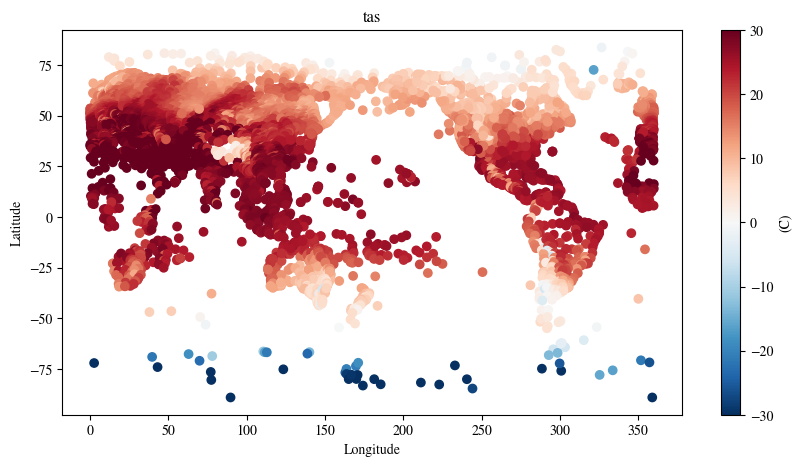

In [9]:
fig = plt.figure(figsize=(10, 5))
plot_channel = 10
p = plt.scatter(
    data["downscaling"]["x_target"][0, 0, :].detach().cpu() * STATION_LON_LAT_SF,
    data["downscaling"]["x_target"][0, 1, :].detach().cpu() * STATION_LON_LAT_SF,
    c=station_forecast_unnorm[0, :],
    vmax=30,
    vmin=-30,
    cmap="RdBu_r",
)
cbar = fig.colorbar(p)
cbar.set_label("(C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"{local_forecast_var}")
plt.show()